In [129]:
# =========================================================
# 1. Imports
# =========================================================

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
from catboost import CatBoostRegressor

# Display settings
sns.set_style("darkgrid", rc={"axes.facecolor": "white", "grid.color": ".8"})
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [130]:
# =========================================================
# 2. Load data
# =========================================================

# Load the feature dataset and parse the timestamp column as datetime
df = pd.read_csv("../data/df_features.csv", parse_dates=["timestamp"])

# Sort the data chronologically and reset the index
df = df.sort_values("timestamp").reset_index(drop=True)

# Show basic checks
print("Shape:", df.shape)
print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())
display(df.head(2))

Shape: (62544, 60)
Date range: 2019-01-16 00:00:00 to 2026-03-05 23:00:00


,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,gas_price,coal_price,price_lag_24h,price_lag_168h,price_rolling_24h,price_rolling_168h,co2_price,is_holiday,is_hol_or_week,total_generation,net_export,coal_generation,gas_generation,nuclear_generation,actual_wind_offshore,actual_wind_onshore,actual_solar,actual_load,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,gas_price_lag_24h,gas_price_lag_168h,coal_price_lag_24h,coal_price_lag_168h,co2_price_lag_24h,renewable_share,fuel_cost_index,dispatchable_gen,demand_supply_gap,is_peak_hour,wind_x_peak,gas_x_peak,solar_x_demand,renewable_share_x_peak,is_crisis_period,is_high_price_regime,is_negative_price,year,residual_load,load_ramp,renewable_ramp,price_volatility_24h,total_wind_forecast,delta_wind_forecast
0,2019-01-16 00:00:00,29.23,54295.0,4647.00,26771.75,0.0,0.0,2.0,1.0,4.9125,36.267860,False,22.004999,83.0,35.18,20.04,45.200000,41.705119,22.81,False,False,69793.75,10571.0,13605.00,5162.5,8970.75,3558.75,30280.00,0.0,55014.00,0.000000,1.000000,0.974928,-0.222521,0.5,0.866025,22.0,21.719999,82.5,82.150002,22.55,0.450166,46.402999,27738.25,-15498.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019.0,22876.25,-2525.75,-2456.25,9.645450,31418.75,1551.5
1,2019-01-16 01:00:00,29.26,52450.0,4561.25,26022.25,0.0,1.0,2.0,1.0,4.8000,34.451492,False,22.004999,83.0,35.82,7.24,44.926667,41.836190,22.81,False,False,67991.75,11379.0,13050.75,4994.5,8959.00,3603.00,29191.25,0.0,52838.75,0.258819,0.965926,0.974928,-0.222521,0.5,0.866025,22.0,21.719999,82.5,82.150002,22.55,0.449812,46.402999,27004.25,-15541.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019.0,21866.50,-1845.00,-835.25,10.008918,30583.50,510.5


In [131]:
# =========================================================
# 3. Define the final feature set
# =========================================================

# Define the final feature set after removing the teammate-flagged leakage features
feature_cols = [
    "load",
    "wind_offshore",
    "wind_onshore",
    "solar",
    "hour",
    "day_of_week",
    "month",
    "temperature",
    "wind_speed",
    "is_weekend",
    "price_lag_24h",
    "price_lag_168h",
    "price_rolling_24h",
    "price_rolling_168h",
    "is_holiday",
    "is_hol_or_week",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "gas_price_lag_24h",
    "gas_price_lag_168h",
    "coal_price_lag_24h",
    "coal_price_lag_168h",
    "co2_price_lag_24h",
    #"fuel_cost_index",
    "is_peak_hour",
    "wind_x_peak",
    #"gas_x_peak",
    "solar_x_demand",
    "renewable_share_x_peak",
    "is_crisis_period",
    "is_high_price_regime",
    "year",
    "price_volatility_24h",
    "total_wind_forecast",
    "delta_wind_forecast",
     "residual_load",
    "load_ramp",
    "renewable_ramp"
]

In [132]:
# =========================================================
# 4. Check the selected feature set
# =========================================================

# Check whether all selected features exist in the dataframe
missing_features = [col for col in feature_cols if col not in df.columns]

# Print missing features
print("Missing features:", missing_features)

# Print number of selected features
print("Number of selected features:", len(feature_cols))

# Show the selected feature names
print(feature_cols)

# Preview the selected feature columns
display(df[feature_cols].head(2))

# Show data type counts
display(df[feature_cols].dtypes.value_counts())

# Show missing values in the selected features
display(df[feature_cols].isna().sum().sort_values(ascending=False).head(20))

Missing features: []
Number of selected features: 40
['load', 'wind_offshore', 'wind_onshore', 'solar', 'hour', 'day_of_week', 'month', 'temperature', 'wind_speed', 'is_weekend', 'price_lag_24h', 'price_lag_168h', 'price_rolling_24h', 'price_rolling_168h', 'is_holiday', 'is_hol_or_week', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'gas_price_lag_24h', 'gas_price_lag_168h', 'coal_price_lag_24h', 'coal_price_lag_168h', 'co2_price_lag_24h', 'is_peak_hour', 'wind_x_peak', 'solar_x_demand', 'renewable_share_x_peak', 'is_crisis_period', 'is_high_price_regime', 'year', 'price_volatility_24h', 'total_wind_forecast', 'delta_wind_forecast', 'residual_load', 'load_ramp', 'renewable_ramp']


,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,price_lag_24h,price_lag_168h,price_rolling_24h,price_rolling_168h,is_holiday,is_hol_or_week,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,gas_price_lag_24h,gas_price_lag_168h,coal_price_lag_24h,coal_price_lag_168h,co2_price_lag_24h,is_peak_hour,wind_x_peak,solar_x_demand,renewable_share_x_peak,is_crisis_period,is_high_price_regime,year,price_volatility_24h,total_wind_forecast,delta_wind_forecast,residual_load,load_ramp,renewable_ramp
0,54295.0,4647.00,26771.75,0.0,0.0,2.0,1.0,4.9125,36.267860,False,35.18,20.04,45.200000,41.705119,False,False,0.000000,1.000000,0.974928,-0.222521,0.5,0.866025,22.0,21.719999,82.5,82.150002,22.55,0.0,0.0,0.0,0.0,0.0,0.0,2019.0,9.645450,31418.75,1551.5,22876.25,-2525.75,-2456.25
1,52450.0,4561.25,26022.25,0.0,1.0,2.0,1.0,4.8000,34.451492,False,35.82,7.24,44.926667,41.836190,False,False,0.258819,0.965926,0.974928,-0.222521,0.5,0.866025,22.0,21.719999,82.5,82.150002,22.55,0.0,0.0,0.0,0.0,0.0,0.0,2019.0,10.008918,30583.50,510.5,21866.50,-1845.00,-835.25


float64    37
bool        3
Name: count, dtype: int64

load                  0
wind_offshore         0
wind_onshore          0
solar                 0
hour                  0
day_of_week           0
month                 0
temperature           0
wind_speed            0
is_weekend            0
price_lag_24h         0
price_lag_168h        0
price_rolling_24h     0
price_rolling_168h    0
is_holiday            0
is_hol_or_week        0
hour_sin              0
hour_cos              0
dow_sin               0
dow_cos               0
dtype: int64

In [133]:
# =========================================================
# 5. Create the hourly train, validation, and test split
# =========================================================

# Create chronological masks
train_mask = df["timestamp"] < "2025-01-01"
val_mask = (df["timestamp"] >= "2025-01-01") & (df["timestamp"] < "2025-07-01")
test_mask = df["timestamp"] >= "2025-07-01"

# Create split dataframes
train_df = df.loc[train_mask].copy()
val_df = df.loc[val_mask].copy()
test_df = df.loc[test_mask].copy()

# Show split shapes
print("train_df:", train_df.shape)
print("val_df:", val_df.shape)
print("test_df:", test_df.shape)

train_df: (52248, 60)
val_df: (4344, 60)
test_df: (5952, 60)


In [134]:
# =========================================================
# 6. Create sample weights for the training period
# =========================================================

# Create default training weights
train_weights = pd.Series(1.0, index=train_df.index)

# Assign regime-based weights
train_weights.loc[(train_df["timestamp"] >= "2019-01-01") & (train_df["timestamp"] < "2021-01-01")] = 0.6
train_weights.loc[(train_df["timestamp"] >= "2021-01-01") & (train_df["timestamp"] < "2023-01-01")] = 0.3
train_weights.loc[(train_df["timestamp"] >= "2023-01-01") & (train_df["timestamp"] < "2025-01-01")] = 1.0

# Show the weight distribution
display(train_weights.value_counts().sort_index())
display(train_weights.head())

0.3    17520
0.6    17184
1.0    17544
Name: count, dtype: int64

0    0.6
1    0.6
2    0.6
3    0.6
4    0.6
dtype: float64

In [135]:
# =========================================================
# 7. Create hourly feature matrices and targets
# =========================================================

# Create feature matrices
X_train = train_df[feature_cols].copy()
X_val = val_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

# Create targets
y_train = train_df["price"].copy()
y_val = val_df["price"].copy()
y_test = test_df["price"].copy()

# Show shapes
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (52248, 40)
X_val: (4344, 40)
X_test: (5952, 40)
y_train: (52248,)
y_val: (4344,)
y_test: (5952,)


In [136]:
# =========================================================
# 8. Build the naive hourly benchmark
# =========================================================

# Define a function for the naive hourly forecast
def predict_price_lag_hourly(df_input, price_col="price", day_col="day_of_week"):
    # Create 24-hour and 168-hour lagged prices
    lag_1 = df_input[price_col].shift(24)
    lag_7 = df_input[price_col].shift(168)

    # Use D-1 for Tue, Wed, Thu, Fri, Sun and D-7 for Mon, Sat
    lag_1_days = {1, 2, 3, 4, 6}

    # Return the naive prediction series
    return pd.Series(
        np.where(df_input[day_col].isin(lag_1_days), lag_1, lag_7),
        index=df_input.index
    )

# Create naive hourly predictions for the full dataframe
df["price_pred_naive"] = predict_price_lag_hourly(df)

# Extract naive predictions for validation and test
y_val_naive = df.loc[val_df.index, "price_pred_naive"].copy()
y_test_naive = df.loc[test_df.index, "price_pred_naive"].copy()

In [137]:
# =========================================================
# 9. Define evaluation metrics
# =========================================================

# Define hourly MAE
def mae_hourly(y_true, y_pred):
    # Compute the mean absolute error
    return mean_absolute_error(y_true, y_pred)

# Define daily average error based on hourly predictions
def dae_hourly(y_true, y_pred, timestamps):
    # Build a temporary dataframe with timestamps, true values, and predictions
    eval_df = pd.DataFrame({
        "timestamp": timestamps,
        "y_true": y_true,
        "y_pred": y_pred
    })

    # Aggregate to daily sums
    daily_eval = eval_df.groupby(eval_df["timestamp"].dt.floor("D")).agg({
        "y_true": "sum",
        "y_pred": "sum"
    })

    # Compute the mean daily average error
    return np.mean(np.abs(daily_eval["y_true"] - daily_eval["y_pred"]) / 24)

# Define relative MAE against the naive benchmark
def rmae(model_mae, naive_mae):
    # Compute relative MAE
    return model_mae / naive_mae

In [138]:
# =========================================================
# 10. Evaluate the naive benchmark
# =========================================================

# Compute naive validation metrics
naive_val_mae = mae_hourly(y_val, y_val_naive)
naive_val_dae = dae_hourly(y_val, y_val_naive, val_df["timestamp"])

# Compute naive test metrics
naive_test_mae = mae_hourly(y_test, y_test_naive)
naive_test_dae = dae_hourly(y_test, y_test_naive, test_df["timestamp"])

# Print validation results
print("Naive validation MAE:", round(naive_val_mae, 4))
print("Naive validation DAE:", round(naive_val_dae, 4))

# Print test results
print("Naive test MAE:", round(naive_test_mae, 4))
print("Naive test DAE:", round(naive_test_dae, 4))

Naive validation MAE: 28.4164
Naive validation DAE: 22.57
Naive test MAE: 23.3474
Naive test DAE: 18.8407


In [139]:
# =========================================================
# 11. Build the Lasso benchmark
# =========================================================

# Build a pipeline with feature scaling and Lasso
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.01, max_iter=10000, random_state=42))
])

# Fit the Lasso model on the training data with sample weights
lasso_model.fit(X_train, y_train, model__sample_weight=train_weights)

# Predict on validation and test data
y_val_pred_lasso = pd.Series(lasso_model.predict(X_val), index=y_val.index)
y_test_pred_lasso = pd.Series(lasso_model.predict(X_test), index=y_test.index)

In [140]:
# =========================================================
# 12. Evaluate the Lasso benchmark
# =========================================================

# Compute Lasso validation metrics
lasso_val_mae = mae_hourly(y_val, y_val_pred_lasso)
lasso_val_dae = dae_hourly(y_val, y_val_pred_lasso, val_df["timestamp"])
lasso_val_rmae = rmae(lasso_val_mae, naive_val_mae)

# Compute Lasso test metrics
lasso_test_mae = mae_hourly(y_test, y_test_pred_lasso)
lasso_test_dae = dae_hourly(y_test, y_test_pred_lasso, test_df["timestamp"])
lasso_test_rmae = rmae(lasso_test_mae, naive_test_mae)

# Print validation results
print("Lasso validation MAE:", round(lasso_val_mae, 4))
print("Lasso validation DAE:", round(lasso_val_dae, 4))
print("Lasso validation RMAE:", round(lasso_val_rmae, 4))

# Print test results
print("Lasso test MAE:", round(lasso_test_mae, 4))
print("Lasso test DAE:", round(lasso_test_dae, 4))
print("Lasso test RMAE:", round(lasso_test_rmae, 4))

Lasso validation MAE: 16.0496
Lasso validation DAE: 9.9316
Lasso validation RMAE: 0.5648
Lasso test MAE: 14.7377
Lasso test DAE: 8.5313
Lasso test RMAE: 0.6312


In [141]:
# =========================================================
# 13. Build the final CatBoost model
# =========================================================

# Combine train and validation data for final training
X_final_train = pd.concat([X_train, X_val], axis=0)
y_final_train = pd.concat([y_train, y_val], axis=0)

# Create final sample weights for the full pre-test period
val_weights = pd.Series(1.0, index=X_val.index)
final_train_weights = pd.concat([train_weights, val_weights], axis=0)

# Build the final CatBoost model with the best local tuning parameters
catboost_model = CatBoostRegressor(
    iterations=350,
    depth=8,
    learning_rate=0.10,
    l2_leaf_reg=3,
    loss_function="MAE",
    eval_metric="MAE",
    verbose=0,
    random_state=42
)

# Fit the final CatBoost model
catboost_model.fit(
    X_final_train,
    y_final_train,
    sample_weight=final_train_weights
)

# Predict on the test set
y_test_pred_catboost = pd.Series(catboost_model.predict(X_test), index=y_test.index)

In [142]:
# =========================================================
# 14. Evaluate the final CatBoost model with the best chosen parameters
# =========================================================

# Compute CatBoost test metrics
catboost_test_mae = mae_hourly(y_test, y_test_pred_catboost)
catboost_test_dae = dae_hourly(y_test, y_test_pred_catboost, test_df["timestamp"])
catboost_test_rmae = rmae(catboost_test_mae, naive_test_mae)

# Print final CatBoost results
print("CatBoost test MAE:", round(catboost_test_mae, 4))
print("CatBoost test DAE:", round(catboost_test_dae, 4))
print("CatBoost test RMAE:", round(catboost_test_rmae, 4))

CatBoost test MAE: 10.1502
CatBoost test DAE: 6.6871
CatBoost test RMAE: 0.4347


In [143]:
# =========================================================
# 15. Final comparison table
# =========================================================

# Create the final comparison table
results_final = pd.DataFrame({
    "model": ["Naive", "Lasso", "CatBoost_Final"],
    "test_MAE": [naive_test_mae, lasso_test_mae, catboost_test_mae],
    "test_DAE": [naive_test_dae, lasso_test_dae, catboost_test_dae],
    "test_RMAE": [1.0, lasso_test_rmae, catboost_test_rmae]
}).round(4)

# Display the final comparison table
display(results_final)

,model,test_MAE,test_DAE,test_RMAE
0,Naive,23.3474,18.8407,1.0000
1,Lasso,14.7377,8.5313,0.6312
2,CatBoost_Final,10.1502,6.6871,0.4347


In [144]:
# =========================================================
# 16. Build hourly evaluation dataframe
# =========================================================

# Build an hourly evaluation dataframe for the test period
eval_hourly = pd.DataFrame({
    "timestamp": test_df["timestamp"].values,
    "actual": y_test.values,
    "naive": y_test_naive.values,
    "lasso": y_test_pred_lasso.values,
    "catboost": y_test_pred_catboost.values
})

# Compute CatBoost residuals
eval_hourly["residual"] = eval_hourly["actual"] - eval_hourly["catboost"]

# Create a daily date column
eval_hourly["date"] = pd.to_datetime(eval_hourly["timestamp"]).dt.floor("D")

# Show the first rows
display(eval_hourly.head())

,timestamp,actual,naive,lasso,catboost,residual,date
0,2025-07-01 00:00:00,111.28,98.73,107.696758,102.196368,9.083632,2025-07-01
1,2025-07-01 01:00:00,95.29,89.03,99.797429,89.927007,5.362993,2025-07-01
2,2025-07-01 02:00:00,89.10,85.03,95.870322,85.994561,3.105439,2025-07-01
3,2025-07-01 03:00:00,88.08,84.13,94.863051,84.161121,3.918879,2025-07-01
4,2025-07-01 04:00:00,90.01,86.51,98.300682,88.018852,1.991148,2025-07-01


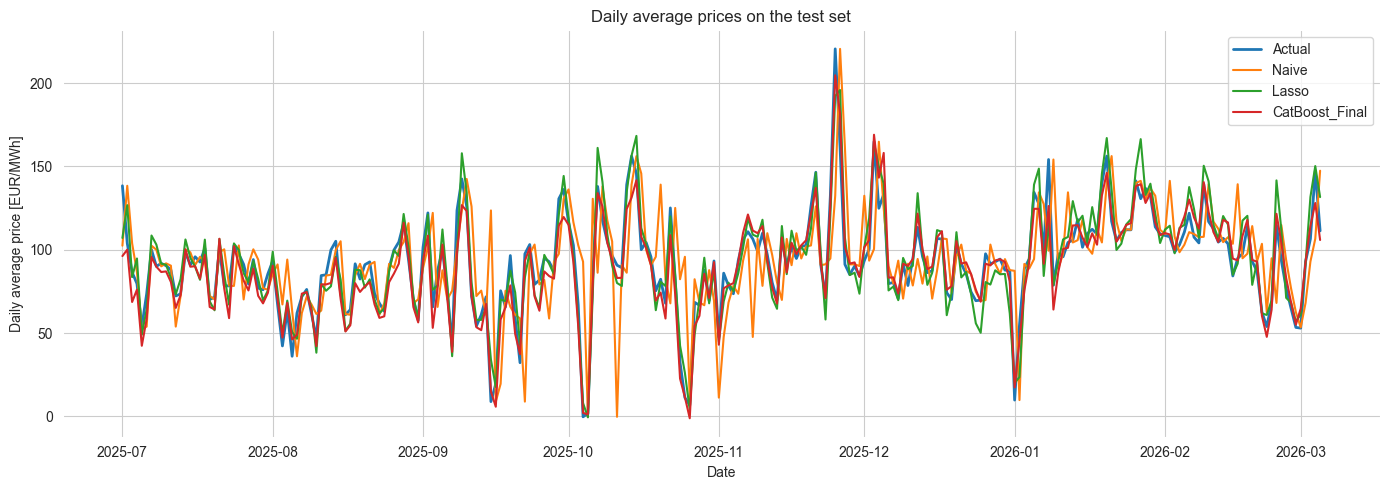

In [145]:
# =========================================================
# 17. Plot daily average prices on the test set
# =========================================================

# Aggregate hourly values to daily average values
eval_daily = eval_hourly.groupby("date")[["actual", "naive", "lasso", "catboost"]].mean().reset_index()

# Plot daily average prices
plt.figure(figsize=(14, 5))
plt.plot(eval_daily["date"], eval_daily["actual"], label="Actual", linewidth=2)
plt.plot(eval_daily["date"], eval_daily["naive"], label="Naive")
plt.plot(eval_daily["date"], eval_daily["lasso"], label="Lasso")
plt.plot(eval_daily["date"], eval_daily["catboost"], label="CatBoost_Final")
plt.xlabel("Date")
plt.ylabel("Daily average price [EUR/MWh]")
plt.title("Daily average prices on the test set")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

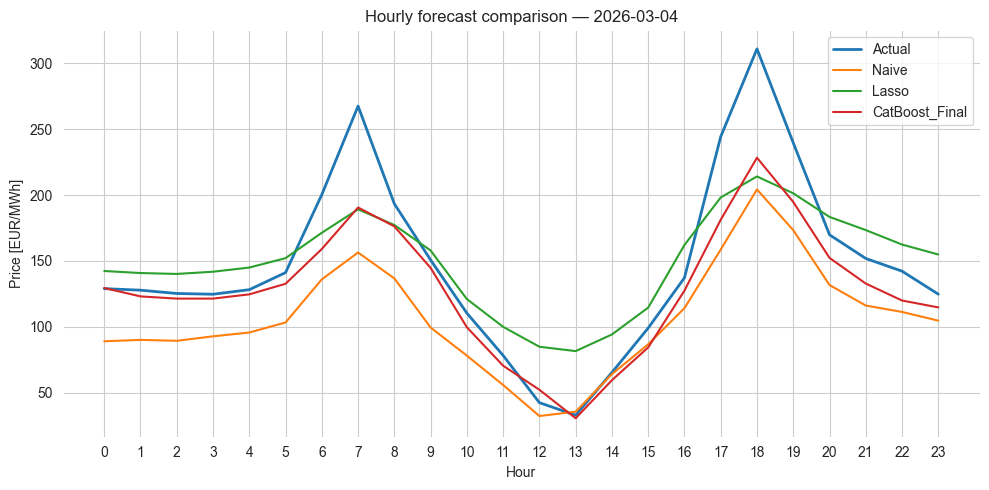

In [146]:
# =========================================================
# 18. Plot actual vs. final model for one example day
# =========================================================

# Select one test day for visual comparison
day = "2026-03-04"

# Create a mask for the selected day
day_mask = test_df["timestamp"].dt.strftime("%Y-%m-%d") == day

# Build a plotting dataframe for the selected day
plot_df = pd.DataFrame({
    "timestamp": test_df.loc[day_mask, "timestamp"].values,
    "actual": y_test.loc[day_mask].values,
    "naive": y_test_naive.loc[day_mask].values,
    "lasso": y_test_pred_lasso.loc[day_mask].values,
    "catboost": y_test_pred_catboost.loc[day_mask].values
})

# Extract the hour from the timestamp
plot_df["hour"] = pd.to_datetime(plot_df["timestamp"]).dt.hour

# Plot hourly prices for the selected day
plt.figure(figsize=(10, 5))
plt.plot(plot_df["hour"], plot_df["actual"], label="Actual", linewidth=2)
plt.plot(plot_df["hour"], plot_df["naive"], label="Naive")
plt.plot(plot_df["hour"], plot_df["lasso"], label="Lasso")
plt.plot(plot_df["hour"], plot_df["catboost"], label="CatBoost_Final")
plt.xlabel("Hour")
plt.ylabel("Price [EUR/MWh]")
plt.title(f"Hourly forecast comparison — {day}")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

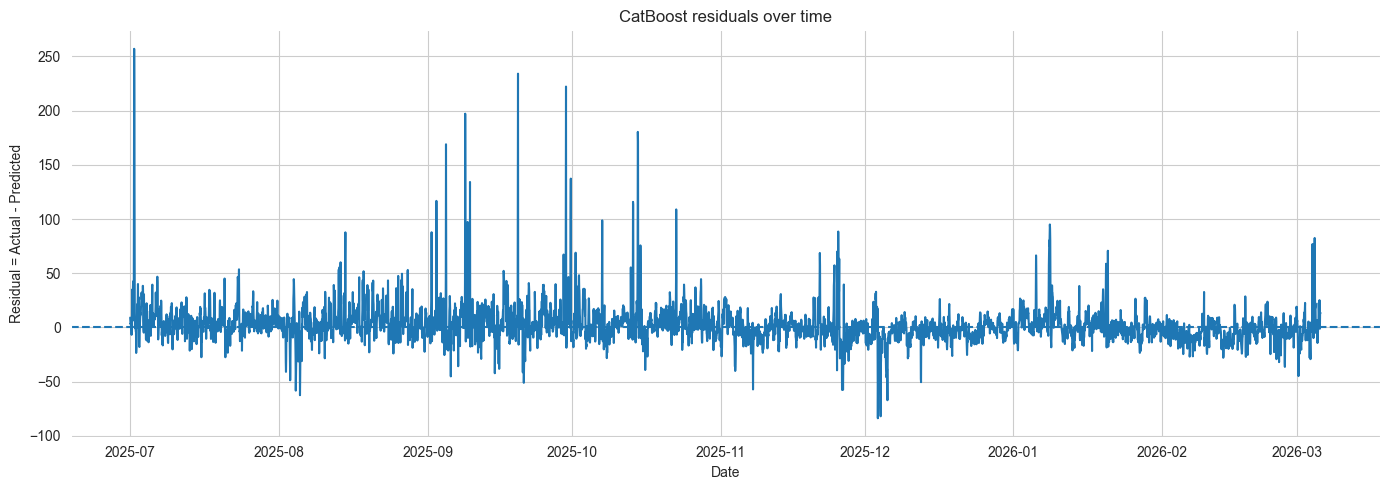

In [147]:
# =========================================================
# 19. Plot residuals over time
# =========================================================

# Plot CatBoost residuals over time
plt.figure(figsize=(14, 5))
plt.plot(eval_hourly["timestamp"], eval_hourly["residual"])
plt.axhline(0, linestyle="--")
plt.xlabel("Date")
plt.ylabel("Residual = Actual - Predicted")
plt.title("CatBoost residuals over time")
plt.grid(True)
plt.tight_layout()
plt.show()

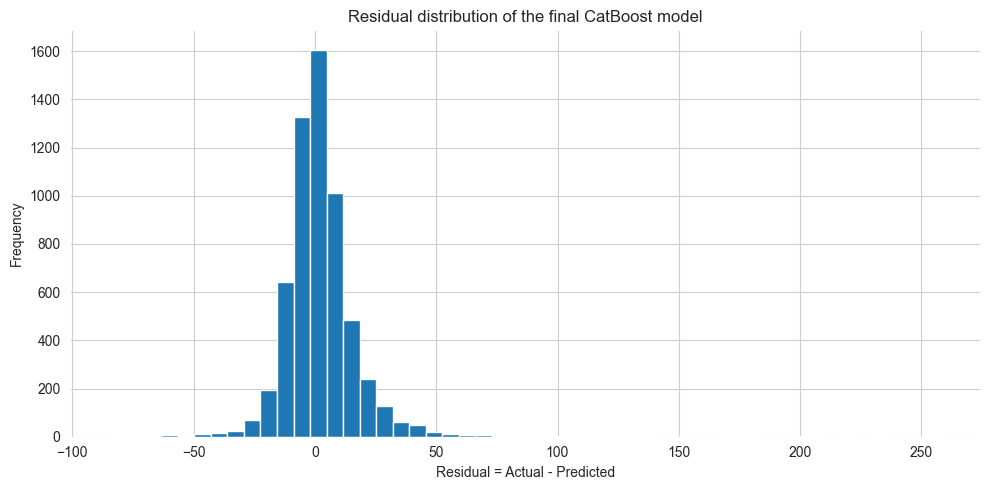

In [148]:
# =========================================================
# 20. Plot residual distribution
# =========================================================

# Plot the residual histogram
plt.figure(figsize=(10, 5))
plt.hist(eval_hourly["residual"], bins=50)
plt.xlabel("Residual = Actual - Predicted")
plt.ylabel("Frequency")
plt.title("Residual distribution of the final CatBoost model")
plt.grid(True)
plt.tight_layout()
plt.show()

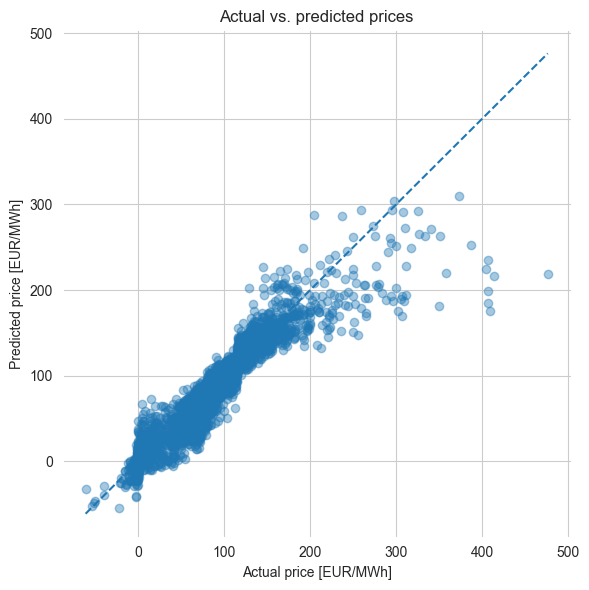

In [149]:
# =========================================================
# 21. Plot actual vs. predicted scatter
# =========================================================

# Plot actual vs predicted values
plt.figure(figsize=(6, 6))
plt.scatter(eval_hourly["actual"], eval_hourly["catboost"], alpha=0.4)

# Plot the 45-degree reference line
min_val = min(eval_hourly["actual"].min(), eval_hourly["catboost"].min())
max_val = max(eval_hourly["actual"].max(), eval_hourly["catboost"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

# Add labels and title
plt.xlabel("Actual price [EUR/MWh]")
plt.ylabel("Predicted price [EUR/MWh]")
plt.title("Actual vs. predicted prices")
plt.grid(True)
plt.tight_layout()
plt.show()

Battery Simulation

In [150]:
# =========================================================
# 1. Define battery parameters for the first BESS model
# =========================================================

# Battery energy capacity [MWh]
# Maximum amount of energy that can be stored in the battery
capacity_mwh = 4.0

# Maximum charging power [MW]
# Maximum energy that can be bought from the grid in one hour
max_charge_mw = 2.0

# Maximum discharging power [MW]
# Maximum energy that can be sold to the grid in one hour
max_discharge_mw = 2.0

# Charging efficiency [-]
# Example: if 1.0 MWh is bought from the grid, only 0.95 MWh is stored
eta_charge = 0.95

# Discharging efficiency [-]
# Example: if 1.0 MWh is sold to the grid, the battery SOC must decrease by more than 1.0 MWh
eta_discharge = 0.95

# Minimum allowed state of charge [MWh]
soc_min_mwh = 0.0

# Maximum allowed state of charge [MWh]
soc_max_mwh = capacity_mwh

# Initial state of charge at the start of the day [MWh]
soc_init_mwh = 2.0

# Required state of charge at the end of the day [MWh]
soc_final_mwh = 2.0

# Length of one time step [hours]
dt = 1.0

# Quick check of all parameter values
print("Battery parameters:")
print(f"capacity_mwh      = {capacity_mwh}")
print(f"max_charge_mw     = {max_charge_mw}")
print(f"max_discharge_mw  = {max_discharge_mw}")
print(f"eta_charge        = {eta_charge}")
print(f"eta_discharge     = {eta_discharge}")
print(f"soc_min_mwh       = {soc_min_mwh}")
print(f"soc_max_mwh       = {soc_max_mwh}")
print(f"soc_init_mwh      = {soc_init_mwh}")
print(f"soc_final_mwh     = {soc_final_mwh}")
print(f"dt                = {dt}")

Battery parameters:
capacity_mwh      = 4.0
max_charge_mw     = 2.0
max_discharge_mw  = 2.0
eta_charge        = 0.95
eta_discharge     = 0.95
soc_min_mwh       = 0.0
soc_max_mwh       = 4.0
soc_init_mwh      = 2.0
soc_final_mwh     = 2.0
dt                = 1.0


### SOC update equation

$$SOC_t = SOC_{t-1} + \eta_{\text{charge}} \cdot charge_t - \frac{discharge_t}{\eta_{\text{discharge}}}$$



In [151]:
# =========================================================
# 2. Define the battery model structure for one day
# =========================================================

# Number of hours in one daily optimization horizon
n_hours = 24

# Create an index for the 24 hourly time steps: 0, 1, ..., 23
hours = range(n_hours)

# Print a short reminder of the modeling convention
print("Battery model convention:")
print("- charge_t   = energy bought from the grid during hour t [MWh]")
print("- discharge_t = energy sold to the grid during hour t [MWh]")
print("- soc_t      = stored energy in the battery at the end of hour t [MWh]")

# Print the SOC update equation that we will use later in the optimization
print("\nSOC update equation:")
print("soc_t = soc_(t-1) + eta_charge * charge_t - discharge_t / eta_discharge")

Battery model convention:
- charge_t   = energy bought from the grid during hour t [MWh]
- discharge_t = energy sold to the grid during hour t [MWh]
- soc_t      = stored energy in the battery at the end of hour t [MWh]

SOC update equation:
soc_t = soc_(t-1) + eta_charge * charge_t - discharge_t / eta_discharge


In [152]:
# =========================================================
# 3. Extract one example day from the hourly evaluation data
# =========================================================

# Choose one day from the test period
example_day = "2026-03-04"

# Filter the hourly evaluation dataframe for that day
day_df = eval_hourly[eval_hourly["date"] == pd.to_datetime(example_day)].copy()

# Keep only the relevant columns and sort by time
day_df = day_df[["timestamp", "actual", "catboost"]].sort_values("timestamp").reset_index(drop=True)

# Add an hour column for easier reading
day_df["hour"] = day_df["timestamp"].dt.hour

# Quick check
print("Selected day:", example_day)
print("Number of hourly rows:", len(day_df))

# Display the 24-hour price table
display(day_df)

Selected day: 2026-03-04
Number of hourly rows: 24


,timestamp,actual,catboost,hour
0,2026-03-04 00:00:00,129.01,129.472562,0
1,2026-03-04 01:00:00,127.82,123.111642,1
2,2026-03-04 02:00:00,125.32,121.438363,2
3,2026-03-04 03:00:00,124.74,121.430042,3
4,2026-03-04 04:00:00,128.20,124.664677,4
5,2026-03-04 05:00:00,141.16,132.688372,5
6,2026-03-04 06:00:00,200.30,159.057398,6
7,2026-03-04 07:00:00,267.49,190.546973,7
8,2026-03-04 08:00:00,193.35,176.234870,8
9,2026-03-04 09:00:00,150.76,144.745909,9


In [153]:
# =========================================================
# 4. Create 24-hour price vectors for optimization
# =========================================================

# Actual price vector for the selected day [EUR/MWh]
prices_actual = day_df["actual"].to_numpy()

# Forecast price vector for the selected day [EUR/MWh]
prices_forecast = day_df["catboost"].to_numpy()

# Quick checks
print("Length of actual price vector:", len(prices_actual))
print("Length of forecast price vector:", len(prices_forecast))

print("\nActual prices:")
print(prices_actual)

print("\nForecast prices:")
print(prices_forecast)

Length of actual price vector: 24
Length of forecast price vector: 24

Actual prices:
[129.01 127.82 125.32 124.74 128.2  141.16 200.3  267.49 193.35 150.76
 110.42  78.3   42.5   32.98  65.41  99.11 137.21 244.27 310.86 239.63
 169.86 151.88 142.24 124.81]

Forecast prices:
[129.4725617  123.11164249 121.43836268 121.4300421  124.66467704
 132.68837164 159.05739821 190.54697329 176.23487019 144.74590948
  99.68510483  70.55249828  52.27925364  30.67751504  59.54759842
  84.40688637 127.51507685 181.21667817 228.31373388 194.74496839
 152.31817664 132.85506203 119.97951203 114.75230845]


## Battery model for one day

We optimize battery operation over 24 hours.

### Decision variables

For each hour \(t = 0,1,\dots,23\):

- \(charge_t\): energy bought from the grid in hour \(t\) \([MWh]\)
- \(discharge_t\): energy sold to the grid in hour \(t\) \([MWh]\)
- \(SOC_t\): battery state of charge at the end of hour \(t\) \([MWh]\)

### Objective

Maximize daily arbitrage profit:

$$
\max \sum_{t=0}^{23} \left( p_t \cdot discharge_t - p_t \cdot charge_t \right)
$$

where \(p_t\) is the electricity price in hour \(t\).

### Constraints

#### 1. SOC update

For hour \(t=0\):

$$
SOC_0 = SOC_{\text{init}} + \eta_{\text{charge}} \cdot charge_0 - \frac{discharge_0}{\eta_{\text{discharge}}}
$$

For hours \(t=1,\dots,23\):

$$
SOC_t = SOC_{t-1} + \eta_{\text{charge}} \cdot charge_t - \frac{discharge_t}{\eta_{\text{discharge}}}
$$

#### 2. SOC bounds

$$
SOC_{\min} \le SOC_t \le SOC_{\max}
$$

#### 3. Charge limit

$$
0 \le charge_t \le P_{\text{charge,max}} \cdot \Delta t
$$

#### 4. Discharge limit

$$
0 \le discharge_t \le P_{\text{discharge,max}} \cdot \Delta t
$$

#### 5. Final SOC

$$
SOC_{23} = SOC_{\text{final}}
$$

### Battery constraints

For each hour \(t\):

#### 1. SOC balance
$$
SOC_t = SOC_{t-1} + \eta_{\text{charge}} \cdot charge_t - \frac{discharge_t}{\eta_{\text{discharge}}}
$$

#### 2. SOC bounds
$$
SOC_{\min} \le SOC_t \le SOC_{\max}
$$

#### 3. Charge power bound
$$
0 \le charge_t \le P_{\text{charge,max}} \cdot \Delta t
$$

#### 4. Discharge power bound
$$
0 \le discharge_t \le P_{\text{discharge,max}} \cdot \Delta t
$$

#### 5. Initial SOC
$$
SOC_{-1} = SOC_{\text{init}}
$$

#### 6. Final SOC
$$
SOC_{23} = SOC_{\text{final}}
$$

In [154]:
# =========================================================
# 5.1 Choose the price vector and define the optimization size
# =========================================================

# We start with perfect foresight for one day:
# the optimizer sees the actual prices of that day
prices = prices_actual.copy()

# Number of hours in the optimization horizon
n = len(prices)

# We will optimize three variable groups:
# 1) charge_0 ... charge_23
# 2) discharge_0 ... discharge_23
# 3) soc_0 ... soc_23
n_vars = 3 * n

print("Number of hours:", n)
print("Total number of optimization variables:", n_vars)

# =========================================================
# 5.2 Define the variable positions
# =========================================================

# Variable order inside the optimization vector x:
# x = [charge variables | discharge variables | soc variables]

charge_start = 0
discharge_start = n
soc_start = 2 * n

print("charge variables:    x[0] to x[23]")
print("discharge variables: x[24] to x[47]")
print("soc variables:       x[48] to x[71]")

# =========================================================
# 5.3 Define the objective vector
# =========================================================

# linprog minimizes.
# But we want to maximize profit:
# profit = sum(price * discharge - price * charge)
#
# So we minimize:
# -profit = sum(price * charge - price * discharge)

c = np.concatenate([
    prices,          # charging costs money
    -prices,         # discharging earns money
    np.zeros(n)      # SOC itself has no direct profit term
])

print("Objective vector shape:", c.shape)
print("First 5 objective values:", c[:5])

Number of hours: 24
Total number of optimization variables: 72
charge variables:    x[0] to x[23]
discharge variables: x[24] to x[47]
soc variables:       x[48] to x[71]
Objective vector shape: (72,)
First 5 objective values: [129.01 127.82 125.32 124.74 128.2 ]


In [155]:
# =========================================================
# 5.4 Define variable bounds
# =========================================================

# Charge bounds:
# In each hour, charging must stay between 0 and the maximum charge amount
charge_bounds = [(0, max_charge_mw * dt) for _ in range(n)]

# Discharge bounds:
# In each hour, discharging must stay between 0 and the maximum discharge amount
discharge_bounds = [(0, max_discharge_mw * dt) for _ in range(n)]

# SOC bounds:
# In each hour, SOC must stay between the minimum and maximum battery capacity limits
soc_bounds = [(soc_min_mwh, soc_max_mwh) for _ in range(n)]

# Combine all bounds in the same order as the optimization variables
bounds = charge_bounds + discharge_bounds + soc_bounds

# Quick checks
print("Number of bounds:", len(bounds))
print("First 3 charge bounds:", charge_bounds[:3])
print("First 3 discharge bounds:", discharge_bounds[:3])
print("First 3 SOC bounds:", soc_bounds[:3])

Number of bounds: 72
First 3 charge bounds: [(0, 2.0), (0, 2.0), (0, 2.0)]
First 3 discharge bounds: [(0, 2.0), (0, 2.0), (0, 2.0)]
First 3 SOC bounds: [(0.0, 4.0), (0.0, 4.0), (0.0, 4.0)]


In [156]:
# =========================================================
# 5.5 Define the equality constraints for SOC
# =========================================================

# We collect all equality constraints in:
# A_eq @ x = b_eq
A_eq = []
b_eq = []

# ---------------------------------------------------------
# SOC equation for hour 0
# SOC_0 = SOC_init + eta_charge * charge_0 - discharge_0 / eta_discharge
# Rearranged for the solver:
# -eta_charge * charge_0 + (1/eta_discharge) * discharge_0 + SOC_0 = SOC_init
# ---------------------------------------------------------
row = np.zeros(n_vars)

# Coefficient of charge_0
row[charge_start + 0] = -eta_charge

# Coefficient of discharge_0
row[discharge_start + 0] = 1 / eta_discharge

# Coefficient of SOC_0
row[soc_start + 0] = 1

A_eq.append(row)
b_eq.append(soc_init_mwh)

# ---------------------------------------------------------
# SOC equations for hours 1 to 23
# SOC_t = SOC_(t-1) + eta_charge * charge_t - discharge_t / eta_discharge
# Rearranged:
# -eta_charge * charge_t + (1/eta_discharge) * discharge_t + SOC_t - SOC_(t-1) = 0
# ---------------------------------------------------------
for t in range(1, n):
    row = np.zeros(n_vars)

    # Coefficient of charge_t
    row[charge_start + t] = -eta_charge

    # Coefficient of discharge_t
    row[discharge_start + t] = 1 / eta_discharge

    # Coefficient of SOC_t
    row[soc_start + t] = 1

    # Coefficient of SOC_(t-1)
    row[soc_start + (t - 1)] = -1

    A_eq.append(row)
    b_eq.append(0)

# ---------------------------------------------------------
# Final SOC constraint
# SOC_23 = SOC_final
# ---------------------------------------------------------
row = np.zeros(n_vars)
row[soc_start + (n - 1)] = 1

A_eq.append(row)
b_eq.append(soc_final_mwh)

# Convert lists to numpy arrays
A_eq = np.array(A_eq)
b_eq = np.array(b_eq)

# Quick checks
print("A_eq shape:", A_eq.shape)
print("b_eq shape:", b_eq.shape)
print("Number of equality constraints:", len(b_eq))

A_eq shape: (25, 72)
b_eq shape: (25,)
Number of equality constraints: 25


In [157]:
# =========================================================
# 5.6 Solve the one-day battery optimization
# =========================================================

# Solve the linear program
result = linprog(
    c=c,           # objective vector
    A_eq=A_eq,     # equality constraint matrix
    b_eq=b_eq,     # equality constraint right-hand side
    bounds=bounds, # variable bounds
    method="highs" # recommended modern LP solver
)

# Check whether the optimization was successful
print("Optimization successful:", result.success)
print("Solver message:", result.message)

Optimization successful: True
Solver message: Optimization terminated successfully. (HiGHS Status 7: Optimal)


In [158]:
# =========================================================
# 5.7 Extract the optimal battery schedule
# =========================================================

# Extract the optimized variable vector
x_opt = result.x

# Extract hourly charging decisions [MWh]
charge_opt = x_opt[charge_start:discharge_start]

# Extract hourly discharging decisions [MWh]
discharge_opt = x_opt[discharge_start:soc_start]

# Extract hourly SOC values [MWh]
soc_opt = x_opt[soc_start:]

# Quick checks
print("Length of charge vector:", len(charge_opt))
print("Length of discharge vector:", len(discharge_opt))
print("Length of SOC vector:", len(soc_opt))

Length of charge vector: 24
Length of discharge vector: 24
Length of SOC vector: 24


In [159]:
# =========================================================
# 5.8 Build a readable one-day battery results table
# =========================================================

# Create a results dataframe for the selected day
bess_day_result = pd.DataFrame({
    "timestamp": day_df["timestamp"],
    "hour": day_df["hour"],
    "price_actual": prices_actual,
    "price_forecast": prices_forecast,
    "charge_mwh": charge_opt,
    "discharge_mwh": discharge_opt,
    "soc_mwh": soc_opt
})

# Calculate hourly cashflow based on actual prices
# Revenue from discharge minus cost of charge
bess_day_result["cashflow_eur"] = (
    bess_day_result["price_actual"] * bess_day_result["discharge_mwh"]
    - bess_day_result["price_actual"] * bess_day_result["charge_mwh"]
)

# Display the result table
display(bess_day_result.round(4))

C:\Users\Josip\AppData\Local\Temp\ipykernel_14784\1140358548.py:24: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(bess_day_result.round(4))


,timestamp,hour,price_actual,price_forecast,charge_mwh,discharge_mwh,soc_mwh,cashflow_eur
0,2026-03-04 00:00:00,0,129.01,129.4726,0.0000,0.0,2.0000,0.0000
1,2026-03-04 01:00:00,1,127.82,123.1116,0.0000,0.0,2.0000,0.0000
2,2026-03-04 02:00:00,2,125.32,121.4384,0.1053,0.0,2.1000,-13.1916
3,2026-03-04 03:00:00,3,124.74,121.4300,2.0000,0.0,4.0000,-249.4800
4,2026-03-04 04:00:00,4,128.20,124.6647,0.0000,0.0,4.0000,0.0000
5,2026-03-04 05:00:00,5,141.16,132.6884,0.0000,-0.0,4.0000,-0.0000
6,2026-03-04 06:00:00,6,200.30,159.0574,0.0000,1.8,2.1053,360.5400
7,2026-03-04 07:00:00,7,267.49,190.5470,0.0000,2.0,0.0000,534.9800
8,2026-03-04 08:00:00,8,193.35,176.2349,0.0000,-0.0,0.0000,-0.0000
9,2026-03-04 09:00:00,9,150.76,144.7459,-0.0000,0.0,0.0000,0.0000


In [160]:
# =========================================================
# 5.9 Calculate daily summary results
# =========================================================

# Total daily profit [EUR]
daily_profit_eur = bess_day_result["cashflow_eur"].sum()

# Total charged energy over the day [MWh]
total_charge_mwh = bess_day_result["charge_mwh"].sum()

# Total discharged energy over the day [MWh]
total_discharge_mwh = bess_day_result["discharge_mwh"].sum()

# Print summary
print(f"Daily profit [EUR]: {daily_profit_eur:.2f}")
print(f"Total charged energy [MWh]: {total_charge_mwh:.4f}")
print(f"Total discharged energy [MWh]: {total_discharge_mwh:.4f}")

Daily profit [EUR]: 1264.93
Total charged energy [MWh]: 8.4211
Total discharged energy [MWh]: 7.6000


In [161]:
# =========================================================
# 5.10 Summarize active charging and discharging hours
# =========================================================

# Small numerical tolerance to ignore tiny solver values
tol = 1e-6

# Hours with charging activity
charge_hours = bess_day_result.loc[bess_day_result["charge_mwh"] > tol, [
    "hour", "price_actual", "charge_mwh", "soc_mwh"
]].copy()

# Hours with discharging activity
discharge_hours = bess_day_result.loc[bess_day_result["discharge_mwh"] > tol, [
    "hour", "price_actual", "discharge_mwh", "soc_mwh"
]].copy()

print("Charging hours:")
display(charge_hours.round(4))

print("Discharging hours:")
display(discharge_hours.round(4))

Charging hours:


,hour,price_actual,charge_mwh,soc_mwh
2,2,125.32,0.1053,2.1
3,3,124.74,2.0000,4.0
12,12,42.50,2.0000,1.9
13,13,32.98,2.0000,3.8
14,14,65.41,0.2105,4.0
22,22,142.24,0.1053,0.1
23,23,124.81,2.0000,2.0


Discharging hours:


,hour,price_actual,discharge_mwh,soc_mwh
6,6,200.30,1.8,2.1053
7,7,267.49,2.0,0.0000
17,17,244.27,1.8,2.1053
18,18,310.86,2.0,0.0000


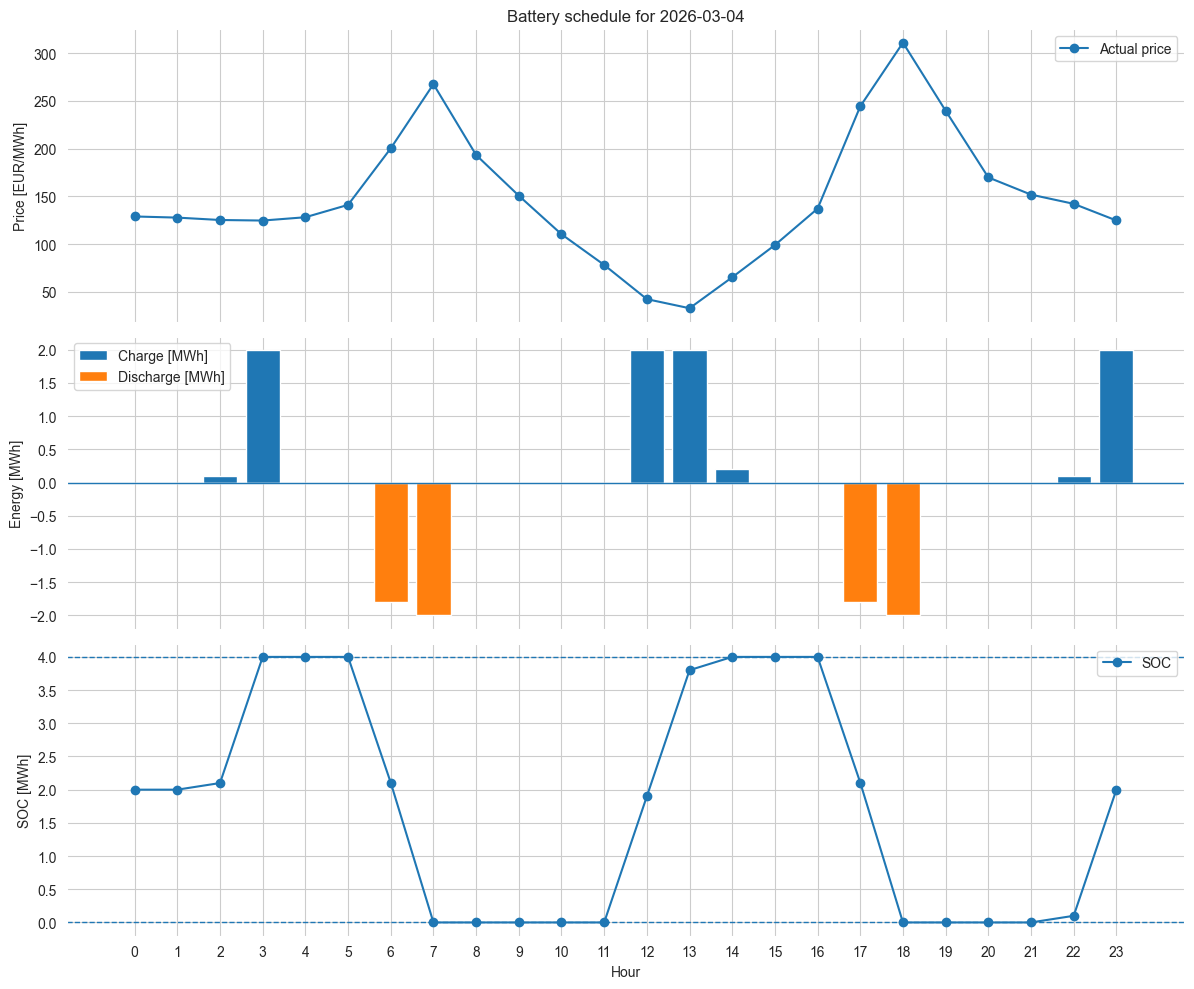

In [162]:
# =========================================================
# 5.11 Plot the one-day battery schedule
# =========================================================

# Plot hourly prices, charge/discharge actions, and SOC for the selected day
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# ---------------------------------------------------------
# 1) Price curve
# ---------------------------------------------------------
axes[0].plot(
    bess_day_result["hour"],
    bess_day_result["price_actual"],
    marker="o",
    label="Actual price"
)
axes[0].set_ylabel("Price [EUR/MWh]")
axes[0].set_title(f"Battery schedule for {example_day}")
axes[0].grid(True)
axes[0].legend()

# ---------------------------------------------------------
# 2) Charge and discharge schedule
# ---------------------------------------------------------
axes[1].bar(
    bess_day_result["hour"],
    bess_day_result["charge_mwh"],
    label="Charge [MWh]"
)

axes[1].bar(
    bess_day_result["hour"],
    -bess_day_result["discharge_mwh"],
    label="Discharge [MWh]"
)

axes[1].axhline(0, linewidth=1)
axes[1].set_ylabel("Energy [MWh]")
axes[1].grid(True)
axes[1].legend()

# ---------------------------------------------------------
# 3) SOC trajectory
# ---------------------------------------------------------
axes[2].plot(
    bess_day_result["hour"],
    bess_day_result["soc_mwh"],
    marker="o",
    label="SOC"
)
axes[2].axhline(soc_min_mwh, linestyle="--", linewidth=1)
axes[2].axhline(soc_max_mwh, linestyle="--", linewidth=1)
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("SOC [MWh]")
axes[2].set_xticks(range(24))
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

## Optimization for all test days

In [163]:
# =========================================================
# 6.1 Define a function to optimize one single day
# =========================================================

def optimize_bess_day(prices, timestamps, hours):
    """
    Solve the daily battery arbitrage problem for one 24-hour price vector.

    Parameters
    ----------
    prices : array-like
        24 hourly electricity prices [EUR/MWh]
    timestamps : array-like
        24 timestamps of the day
    hours : array-like
        24 hour values (0 to 23)

    Returns
    -------
    day_result : pd.DataFrame
        Hourly battery schedule and cashflows
    daily_summary : dict
        Daily summary values
    """

    # Convert prices to numpy array
    prices = np.asarray(prices)
    n = len(prices)

    # Total number of optimization variables:
    # charge_0...charge_23, discharge_0...discharge_23, soc_0...soc_23
    n_vars = 3 * n

    # Variable block positions
    charge_start = 0
    discharge_start = n
    soc_start = 2 * n

    # -----------------------------------------------------
    # Objective vector
    # linprog minimizes, so we minimize negative profit
    # -----------------------------------------------------
    c = np.concatenate([
        prices,           # charging = cost
        -prices,          # discharging = revenue
        np.zeros(n)       # SOC has no direct profit term
    ])

    # -----------------------------------------------------
    # Bounds
    # -----------------------------------------------------
    charge_bounds = [(0, max_charge_mw * dt) for _ in range(n)]
    discharge_bounds = [(0, max_discharge_mw * dt) for _ in range(n)]
    soc_bounds = [(soc_min_mwh, soc_max_mwh) for _ in range(n)]
    bounds = charge_bounds + discharge_bounds + soc_bounds

    # -----------------------------------------------------
    # Equality constraints: SOC equations + final SOC
    # -----------------------------------------------------
    A_eq = []
    b_eq = []

    # Hour 0 SOC equation
    row = np.zeros(n_vars)
    row[charge_start + 0] = -eta_charge
    row[discharge_start + 0] = 1 / eta_discharge
    row[soc_start + 0] = 1
    A_eq.append(row)
    b_eq.append(soc_init_mwh)

    # Hours 1 to 23 SOC equations
    for t in range(1, n):
        row = np.zeros(n_vars)
        row[charge_start + t] = -eta_charge
        row[discharge_start + t] = 1 / eta_discharge
        row[soc_start + t] = 1
        row[soc_start + (t - 1)] = -1
        A_eq.append(row)
        b_eq.append(0)

    # Final SOC
    row = np.zeros(n_vars)
    row[soc_start + (n - 1)] = 1
    A_eq.append(row)
    b_eq.append(soc_final_mwh)

    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)

    # -----------------------------------------------------
    # Solve
    # -----------------------------------------------------
    result = linprog(
        c=c,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=bounds,
        method="highs"
    )

    # Stop if optimization failed
    if not result.success:
        raise ValueError(f"Optimization failed: {result.message}")

    # -----------------------------------------------------
    # Extract solution
    # -----------------------------------------------------
    x_opt = result.x
    charge_opt = x_opt[charge_start:discharge_start]
    discharge_opt = x_opt[discharge_start:soc_start]
    soc_opt = x_opt[soc_start:]

    # -----------------------------------------------------
    # Build hourly result table
    # -----------------------------------------------------
    day_result = pd.DataFrame({
        "timestamp": timestamps,
        "hour": hours,
        "price": prices,
        "charge_mwh": charge_opt,
        "discharge_mwh": discharge_opt,
        "soc_mwh": soc_opt
    })

    # Hourly cashflow based on the same price vector used for optimization
    day_result["cashflow_eur"] = (
        day_result["price"] * day_result["discharge_mwh"]
        - day_result["price"] * day_result["charge_mwh"]
    )

    # -----------------------------------------------------
    # Daily summary
    # -----------------------------------------------------
    daily_summary = {
        "date": pd.to_datetime(day_result["timestamp"]).dt.floor("D").iloc[0],
        "daily_profit_eur": day_result["cashflow_eur"].sum(),
        "total_charge_mwh": day_result["charge_mwh"].sum(),
        "total_discharge_mwh": day_result["discharge_mwh"].sum()
    }

    return day_result, daily_summary

In [164]:
# =========================================================
# 6.2 Run perfect-foresight optimization for all test days
# =========================================================

# Collect hourly and daily outputs
all_day_results = []
all_day_summaries = []

# Loop over all days in the test period
for date, group in eval_hourly.groupby("date"):

    # Sort one daily block by timestamp
    group = group.sort_values("timestamp").reset_index(drop=True)

    # Skip incomplete days
    if len(group) != 24:
        continue

    # Solve the battery optimization using actual prices
    day_result, daily_summary = optimize_bess_day(
        prices=group["actual"].to_numpy(),
        timestamps=group["timestamp"].to_numpy(),
        hours=group["timestamp"].dt.hour.to_numpy()
    )

    # Add date column explicitly
    day_result["date"] = date

    # Store outputs
    all_day_results.append(day_result)
    all_day_summaries.append(daily_summary)

# Combine all results into dataframes
bess_hourly_perfect = pd.concat(all_day_results, ignore_index=True)
bess_daily_perfect = pd.DataFrame(all_day_summaries)

# Quick checks
print("Number of optimized days:", len(bess_daily_perfect))
display(bess_daily_perfect.head())

Number of optimized days: 248


,date,daily_profit_eur,total_charge_mwh,total_discharge_mwh
0,2025-07-01,1462.152842,10.526316,9.500
1,2025-07-02,707.727105,10.526316,9.500
2,2025-07-03,463.356484,8.315789,7.505
3,2025-07-04,560.080089,12.105263,10.925
4,2025-07-05,442.051522,12.110803,10.930


In [165]:
# =========================================================
# 7. Summarize perfect-foresight results over the test period
# =========================================================

# Total profit over all optimized test days [EUR]
total_profit_perfect_eur = bess_daily_perfect["daily_profit_eur"].sum()

# Average daily profit [EUR/day]
avg_daily_profit_perfect_eur = bess_daily_perfect["daily_profit_eur"].mean()

# Total charged energy over the whole test period [MWh]
total_charge_perfect_mwh = bess_daily_perfect["total_charge_mwh"].sum()

# Total discharged energy over the whole test period [MWh]
total_discharge_perfect_mwh = bess_daily_perfect["total_discharge_mwh"].sum()

# Print summary
print(f"Number of optimized days: {len(bess_daily_perfect)}")
print(f"Total perfect-foresight profit [EUR]: {total_profit_perfect_eur:.2f}")
print(f"Average daily profit [EUR/day]: {avg_daily_profit_perfect_eur:.2f}")
print(f"Total charged energy [MWh]: {total_charge_perfect_mwh:.2f}")
print(f"Total discharged energy [MWh]: {total_discharge_perfect_mwh:.2f}")

Number of optimized days: 248
Total perfect-foresight profit [EUR]: 98058.46
Average daily profit [EUR/day]: 395.40
Total charged energy [MWh]: 2243.10
Total discharged energy [MWh]: 2024.40


Forecast-based operation

In [166]:
# =========================================================
# 8.1 Define a function for forecast-based battery optimization
# =========================================================

def optimize_bess_day_with_settlement(opt_prices, settle_prices, timestamps, hours):
    """
    Optimize the battery schedule using one price vector,
    then calculate realized cashflow using another price vector.
    """

    # Convert price inputs to numpy arrays
    opt_prices = np.asarray(opt_prices)
    settle_prices = np.asarray(settle_prices)

    # Number of hours
    n = len(opt_prices)
    n_vars = 3 * n

    # Variable block positions
    charge_start = 0
    discharge_start = n
    soc_start = 2 * n

    # -----------------------------------------------------
    # Objective: optimize using opt_prices
    # -----------------------------------------------------
    c = np.concatenate([
        opt_prices,
        -opt_prices,
        np.zeros(n)
    ])

    # -----------------------------------------------------
    # Bounds
    # -----------------------------------------------------
    charge_bounds = [(0, max_charge_mw * dt) for _ in range(n)]
    discharge_bounds = [(0, max_discharge_mw * dt) for _ in range(n)]
    soc_bounds = [(soc_min_mwh, soc_max_mwh) for _ in range(n)]
    bounds = charge_bounds + discharge_bounds + soc_bounds

    # -----------------------------------------------------
    # Equality constraints
    # -----------------------------------------------------
    A_eq = []
    b_eq = []

    # Hour 0
    row = np.zeros(n_vars)
    row[charge_start + 0] = -eta_charge
    row[discharge_start + 0] = 1 / eta_discharge
    row[soc_start + 0] = 1
    A_eq.append(row)
    b_eq.append(soc_init_mwh)

    # Hours 1 to 23
    for t in range(1, n):
        row = np.zeros(n_vars)
        row[charge_start + t] = -eta_charge
        row[discharge_start + t] = 1 / eta_discharge
        row[soc_start + t] = 1
        row[soc_start + (t - 1)] = -1
        A_eq.append(row)
        b_eq.append(0)

    # Final SOC
    row = np.zeros(n_vars)
    row[soc_start + (n - 1)] = 1
    A_eq.append(row)
    b_eq.append(soc_final_mwh)

    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)

    # -----------------------------------------------------
    # Solve
    # -----------------------------------------------------
    result = linprog(
        c=c,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=bounds,
        method="highs"
    )

    if not result.success:
        raise ValueError(f"Optimization failed: {result.message}")

    # -----------------------------------------------------
    # Extract solution
    # -----------------------------------------------------
    x_opt = result.x
    charge_opt = x_opt[charge_start:discharge_start]
    discharge_opt = x_opt[discharge_start:soc_start]
    soc_opt = x_opt[soc_start:]

    # -----------------------------------------------------
    # Build result table
    # -----------------------------------------------------
    day_result = pd.DataFrame({
        "timestamp": timestamps,
        "hour": hours,
        "price_opt": opt_prices,
        "price_settle": settle_prices,
        "charge_mwh": charge_opt,
        "discharge_mwh": discharge_opt,
        "soc_mwh": soc_opt
    })

    # Realized hourly cashflow uses settlement prices
    day_result["cashflow_eur"] = (
        day_result["price_settle"] * day_result["discharge_mwh"]
        - day_result["price_settle"] * day_result["charge_mwh"]
    )

    # Daily summary
    daily_summary = {
        "date": pd.to_datetime(day_result["timestamp"]).dt.floor("D").iloc[0],
        "daily_profit_eur": day_result["cashflow_eur"].sum(),
        "total_charge_mwh": day_result["charge_mwh"].sum(),
        "total_discharge_mwh": day_result["discharge_mwh"].sum()
    }

    return day_result, daily_summary

In [167]:
# =========================================================
# 8.2 Run forecast-based optimization for all test days
# =========================================================

# Lists to collect hourly and daily outputs
all_day_results_fc = []
all_day_summaries_fc = []

# Loop over each day in the test set
for date, group in eval_hourly.groupby("date"):

    # Sort one daily block by time
    group = group.sort_values("timestamp").reset_index(drop=True)

    # Skip incomplete days
    if len(group) != 24:
        continue

    # Optimize using forecast prices, settle with actual prices
    day_result, daily_summary = optimize_bess_day_with_settlement(
        opt_prices=group["catboost"].to_numpy(),
        settle_prices=group["actual"].to_numpy(),
        timestamps=group["timestamp"].to_numpy(),
        hours=group["timestamp"].dt.hour.to_numpy()
    )

    # Add date column to hourly results
    day_result["date"] = date

    # Store outputs
    all_day_results_fc.append(day_result)
    all_day_summaries_fc.append(daily_summary)

# Combine all results into dataframes
bess_hourly_forecast = pd.concat(all_day_results_fc, ignore_index=True)
bess_daily_forecast = pd.DataFrame(all_day_summaries_fc)

# Quick check
print("Number of optimized days:", len(bess_daily_forecast))
display(bess_daily_forecast.head())

Number of optimized days: 248


,date,daily_profit_eur,total_charge_mwh,total_discharge_mwh
0,2025-07-01,1438.692842,10.526316,9.500
1,2025-07-02,677.030263,10.526316,9.500
2,2025-07-03,439.028824,10.421053,9.405
3,2025-07-04,557.665863,12.210526,11.020
4,2025-07-05,436.234900,20.000000,18.050


In [168]:
# =========================================================
# 8.3 Summarize forecast-based results
# =========================================================

# Total realized profit over all optimized test days [EUR]
total_profit_forecast_eur = bess_daily_forecast["daily_profit_eur"].sum()

# Average daily realized profit [EUR/day]
avg_daily_profit_forecast_eur = bess_daily_forecast["daily_profit_eur"].mean()

# Print summary
print(f"Number of optimized days: {len(bess_daily_forecast)}")
print(f"Total forecast-based profit [EUR]: {total_profit_forecast_eur:.2f}")
print(f"Average daily profit [EUR/day]: {avg_daily_profit_forecast_eur:.2f}")

Number of optimized days: 248
Total forecast-based profit [EUR]: 92743.41
Average daily profit [EUR/day]: 373.97


Random March day: 2026-03-04


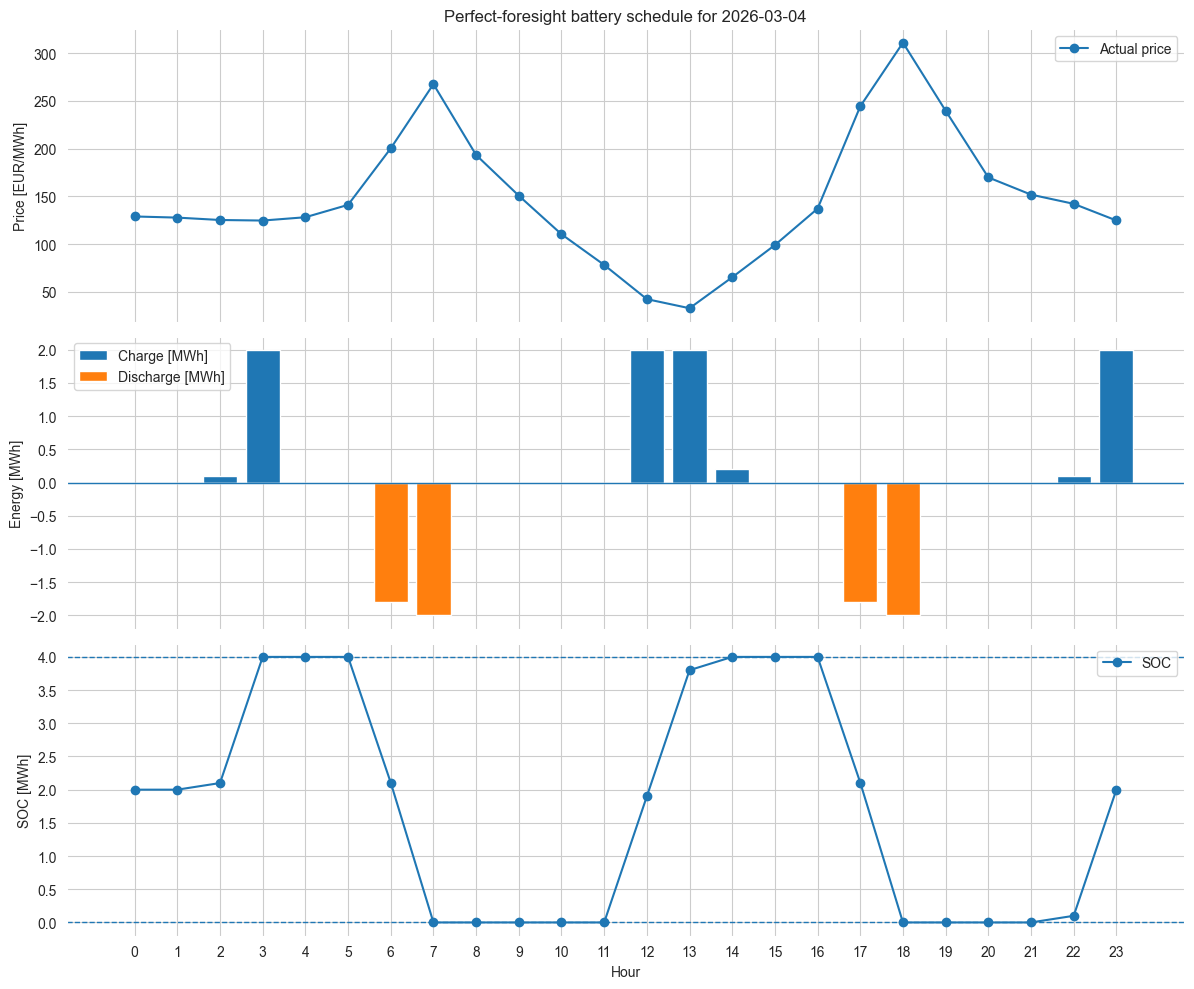

In [169]:
# =========================================================
# 8.4 Plot one random March day from perfect-foresight results
# =========================================================

# Set a seed so the random choice is reproducible
np.random.seed(42)

# Keep only March days from the hourly perfect-foresight results
march_days = bess_hourly_perfect.loc[
    bess_hourly_perfect["timestamp"].dt.month == 3, "date"
].drop_duplicates()

# Randomly choose one March day
random_march_day = np.random.choice(march_days)

# Filter the hourly results for that day
plot_day = bess_hourly_perfect[bess_hourly_perfect["date"] == random_march_day].copy()

# Plot hourly prices, charge/discharge actions, and SOC
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# ---------------------------------------------------------
# 1) Price curve
# ---------------------------------------------------------
axes[0].plot(
    plot_day["hour"],
    plot_day["price"],
    marker="o",
    label="Actual price"
)
axes[0].set_ylabel("Price [EUR/MWh]")
axes[0].set_title(f"Perfect-foresight battery schedule for {pd.to_datetime(random_march_day).date()}")
axes[0].grid(True)
axes[0].legend()

# ---------------------------------------------------------
# 2) Charge and discharge schedule
# ---------------------------------------------------------
axes[1].bar(
    plot_day["hour"],
    plot_day["charge_mwh"],
    label="Charge [MWh]"
)

axes[1].bar(
    plot_day["hour"],
    -plot_day["discharge_mwh"],
    label="Discharge [MWh]"
)

axes[1].axhline(0, linewidth=1)
axes[1].set_ylabel("Energy [MWh]")
axes[1].grid(True)
axes[1].legend()

# ---------------------------------------------------------
# 3) SOC trajectory
# ---------------------------------------------------------
axes[2].plot(
    plot_day["hour"],
    plot_day["soc_mwh"],
    marker="o",
    label="SOC"
)
axes[2].axhline(soc_min_mwh, linestyle="--", linewidth=1)
axes[2].axhline(soc_max_mwh, linestyle="--", linewidth=1)
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("SOC [MWh]")
axes[2].set_xticks(range(24))
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
#plt.show()

# Print the selected random day
print("Random March day:", pd.to_datetime(random_march_day).date())

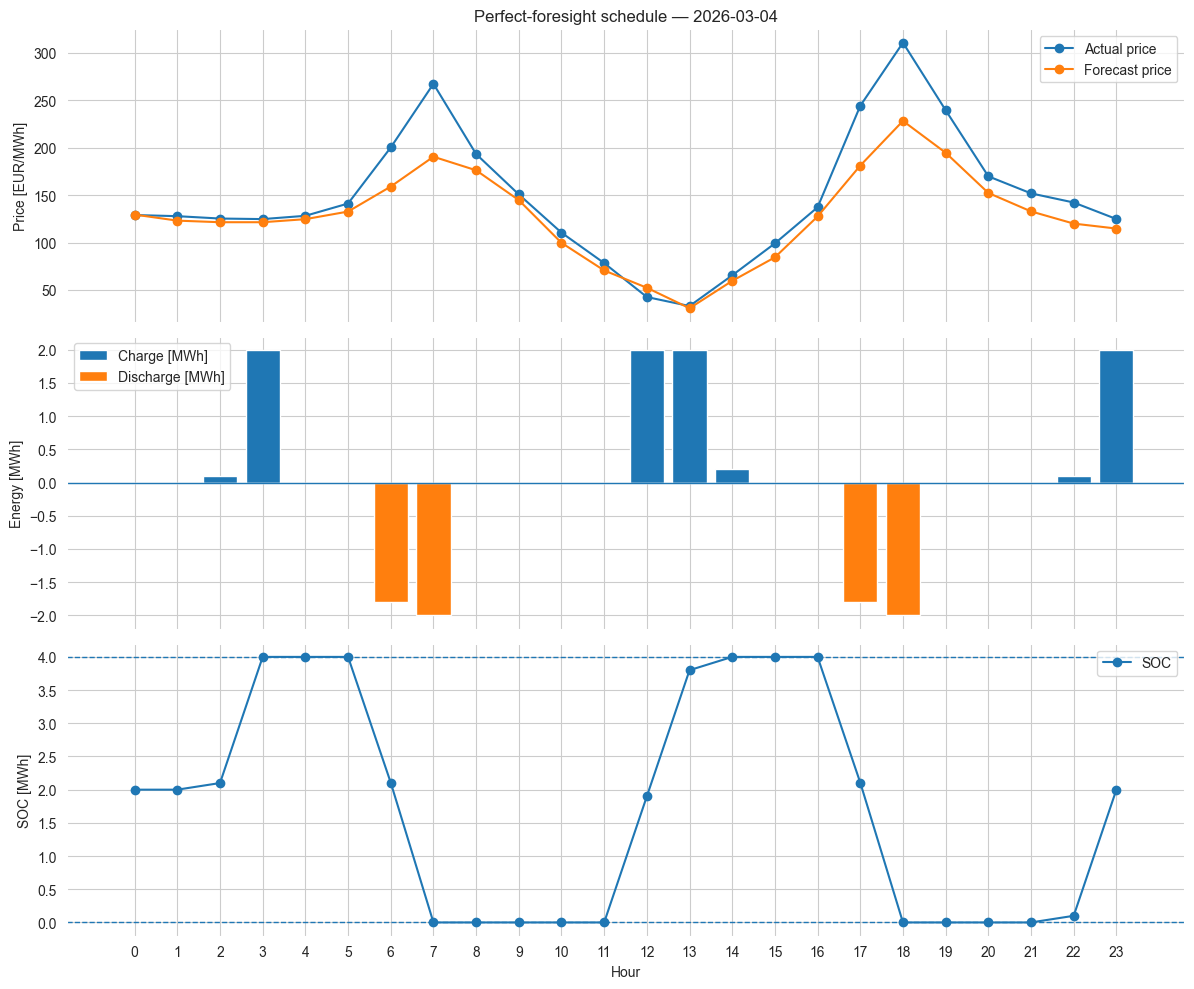

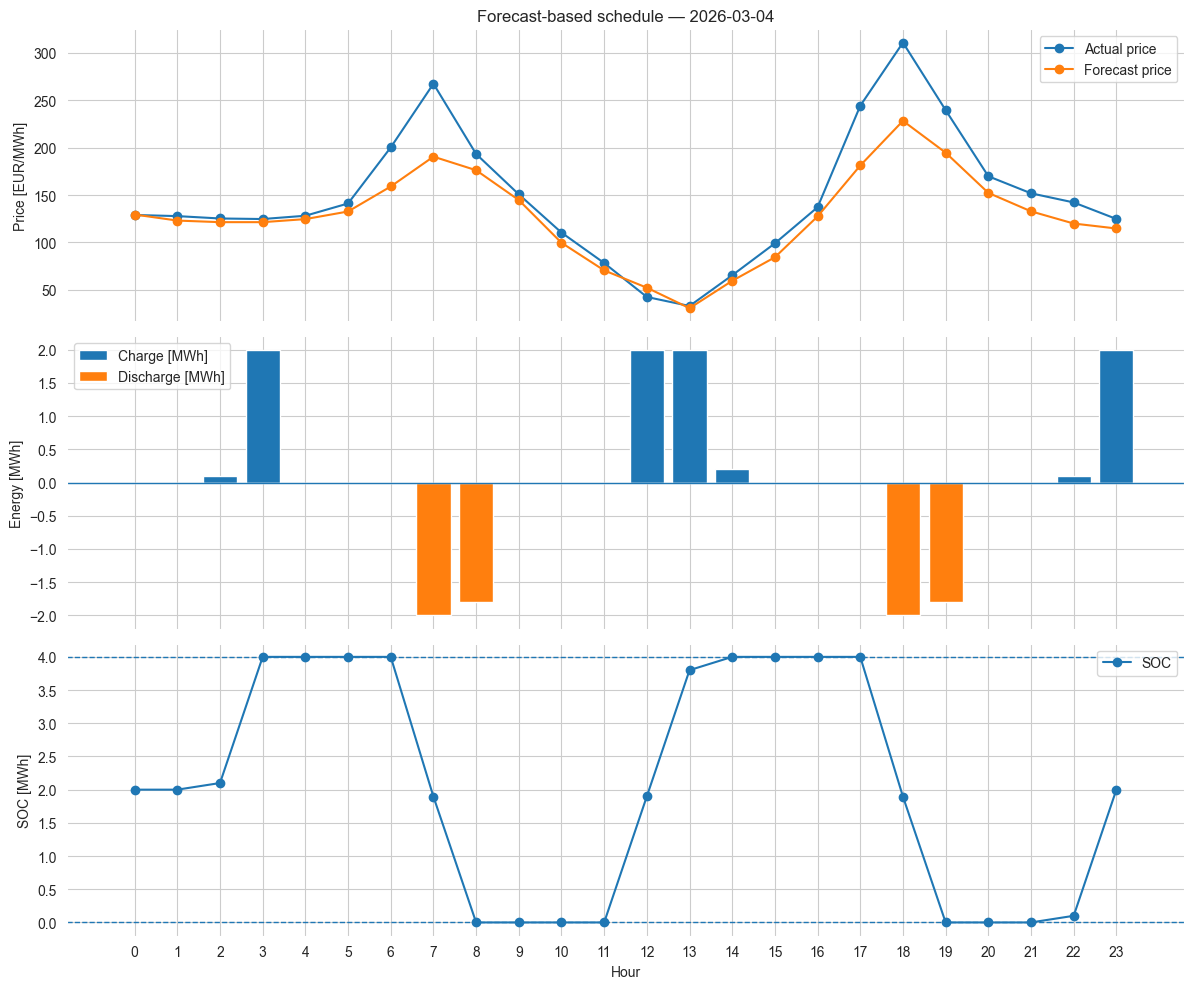

Comparison day: 2026-03-04
Perfect-foresight profit [EUR]: 1264.93
Forecast-based profit [EUR]:   1244.07
Profit gap [EUR]:              20.86


In [170]:
# =========================================================
# 8.5 Compare perfect-foresight vs forecast-based schedule
#     for the same selected random March day
# =========================================================

# Keep the same day chosen before
compare_day = pd.to_datetime(random_march_day)

# -----------------------------------------------
# Perfect-foresight result for that day
# -----------------------------------------------
plot_day_perfect = bess_hourly_perfect[
    bess_hourly_perfect["date"] == compare_day
].copy()

# -----------------------------------------------
# Forecast-based result for that day
# -----------------------------------------------
plot_day_forecast = bess_hourly_forecast[
    bess_hourly_forecast["date"] == compare_day
].copy()

# -----------------------------------------------
# Original actual + forecast price curves
# -----------------------------------------------
price_day = eval_hourly[eval_hourly["date"] == compare_day].copy()
price_day = price_day.sort_values("timestamp").reset_index(drop=True)

# -----------------------------------------------
# Compute daily profits for that same day
# -----------------------------------------------
profit_perfect = plot_day_perfect["cashflow_eur"].sum()
profit_forecast = plot_day_forecast["cashflow_eur"].sum()

# =========================================================
# Plot perfect-foresight schedule
# =========================================================
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1) Price curves
axes[0].plot(
    price_day["timestamp"].dt.hour,
    price_day["actual"],
    marker="o",
    label="Actual price"
)
axes[0].plot(
    price_day["timestamp"].dt.hour,
    price_day["catboost"],
    marker="o",
    label="Forecast price"
)
axes[0].set_ylabel("Price [EUR/MWh]")
axes[0].set_title(f"Perfect-foresight schedule — {compare_day.date()}")
axes[0].grid(True)
axes[0].legend()

# 2) Charge/discharge
axes[1].bar(
    plot_day_perfect["hour"],
    plot_day_perfect["charge_mwh"],
    label="Charge [MWh]"
)
axes[1].bar(
    plot_day_perfect["hour"],
    -plot_day_perfect["discharge_mwh"],
    label="Discharge [MWh]"
)
axes[1].axhline(0, linewidth=1)
axes[1].set_ylabel("Energy [MWh]")
axes[1].grid(True)
axes[1].legend()

# 3) SOC
axes[2].plot(
    plot_day_perfect["hour"],
    plot_day_perfect["soc_mwh"],
    marker="o",
    label="SOC"
)
axes[2].axhline(soc_min_mwh, linestyle="--", linewidth=1)
axes[2].axhline(soc_max_mwh, linestyle="--", linewidth=1)
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("SOC [MWh]")
axes[2].set_xticks(range(24))
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

# =========================================================
# Plot forecast-based schedule
# =========================================================
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1) Price curves
axes[0].plot(
    price_day["timestamp"].dt.hour,
    price_day["actual"],
    marker="o",
    label="Actual price"
)
axes[0].plot(
    price_day["timestamp"].dt.hour,
    price_day["catboost"],
    marker="o",
    label="Forecast price"
)
axes[0].set_ylabel("Price [EUR/MWh]")
axes[0].set_title(f"Forecast-based schedule — {compare_day.date()}")
axes[0].grid(True)
axes[0].legend()

# 2) Charge/discharge
axes[1].bar(
    plot_day_forecast["hour"],
    plot_day_forecast["charge_mwh"],
    label="Charge [MWh]"
)
axes[1].bar(
    plot_day_forecast["hour"],
    -plot_day_forecast["discharge_mwh"],
    label="Discharge [MWh]"
)
axes[1].axhline(0, linewidth=1)
axes[1].set_ylabel("Energy [MWh]")
axes[1].grid(True)
axes[1].legend()

# 3) SOC
axes[2].plot(
    plot_day_forecast["hour"],
    plot_day_forecast["soc_mwh"],
    marker="o",
    label="SOC"
)
axes[2].axhline(soc_min_mwh, linestyle="--", linewidth=1)
axes[2].axhline(soc_max_mwh, linestyle="--", linewidth=1)
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("SOC [MWh]")
axes[2].set_xticks(range(24))
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

# =========================================================
# Print daily profit comparison
# =========================================================
print(f"Comparison day: {compare_day.date()}")
print(f"Perfect-foresight profit [EUR]: {profit_perfect:.2f}")
print(f"Forecast-based profit [EUR]:   {profit_forecast:.2f}")
print(f"Profit gap [EUR]:              {profit_perfect - profit_forecast:.2f}")

In [171]:
# =========================================================
# 9.1 Build a comparison table: perfect foresight vs forecast-based
# =========================================================

# Create a compact summary table
bess_comparison = pd.DataFrame({
    "scenario": ["Perfect_Foresight", "Forecast_Based"],
    "total_profit_eur": [
        bess_daily_perfect["daily_profit_eur"].sum(),
        bess_daily_forecast["daily_profit_eur"].sum()
    ],
    "avg_daily_profit_eur": [
        bess_daily_perfect["daily_profit_eur"].mean(),
        bess_daily_forecast["daily_profit_eur"].mean()
    ],
    "total_charge_mwh": [
        bess_daily_perfect["total_charge_mwh"].sum(),
        bess_daily_forecast["total_charge_mwh"].sum()
    ],
    "total_discharge_mwh": [
        bess_daily_perfect["total_discharge_mwh"].sum(),
        bess_daily_forecast["total_discharge_mwh"].sum()
    ]
})

# Add profit loss of forecast-based operation relative to perfect foresight
profit_gap_total = (
    bess_daily_perfect["daily_profit_eur"].sum()
    - bess_daily_forecast["daily_profit_eur"].sum()
)

avg_profit_gap_daily = (
    bess_daily_perfect["daily_profit_eur"].mean()
    - bess_daily_forecast["daily_profit_eur"].mean()
)

# Show the table
display(bess_comparison.round(2))

print(f"Total profit gap [EUR]: {profit_gap_total:.2f}")
print(f"Average daily profit gap [EUR/day]: {avg_profit_gap_daily:.2f}")

,scenario,total_profit_eur,avg_daily_profit_eur,total_charge_mwh,total_discharge_mwh
0,Perfect_Foresight,98058.46,395.40,2243.1,2024.40
1,Forecast_Based,92743.41,373.97,2305.1,2080.35


Total profit gap [EUR]: 5315.05
Average daily profit gap [EUR/day]: 21.43


In [172]:
# =========================================================
# 9.2 Build a daily profit comparison table
# =========================================================

# Merge daily profits from both scenarios on date
daily_profit_compare = bess_daily_perfect[["date", "daily_profit_eur"]].rename(
    columns={"daily_profit_eur": "profit_perfect_eur"}
).merge(
    bess_daily_forecast[["date", "daily_profit_eur"]].rename(
        columns={"daily_profit_eur": "profit_forecast_eur"}
    ),
    on="date",
    how="inner"
)

# Daily profit gap
daily_profit_compare["profit_gap_eur"] = (
    daily_profit_compare["profit_perfect_eur"]
    - daily_profit_compare["profit_forecast_eur"]
)

# Show first rows
display(daily_profit_compare.head().round(2))

C:\Users\Josip\AppData\Local\Temp\ipykernel_14784\823183769.py:23: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(daily_profit_compare.head().round(2))


,date,profit_perfect_eur,profit_forecast_eur,profit_gap_eur
0,2025-07-01,1462.15,1438.69,23.46
1,2025-07-02,707.73,677.03,30.70
2,2025-07-03,463.36,439.03,24.33
3,2025-07-04,560.08,557.67,2.41
4,2025-07-05,442.05,436.23,5.82


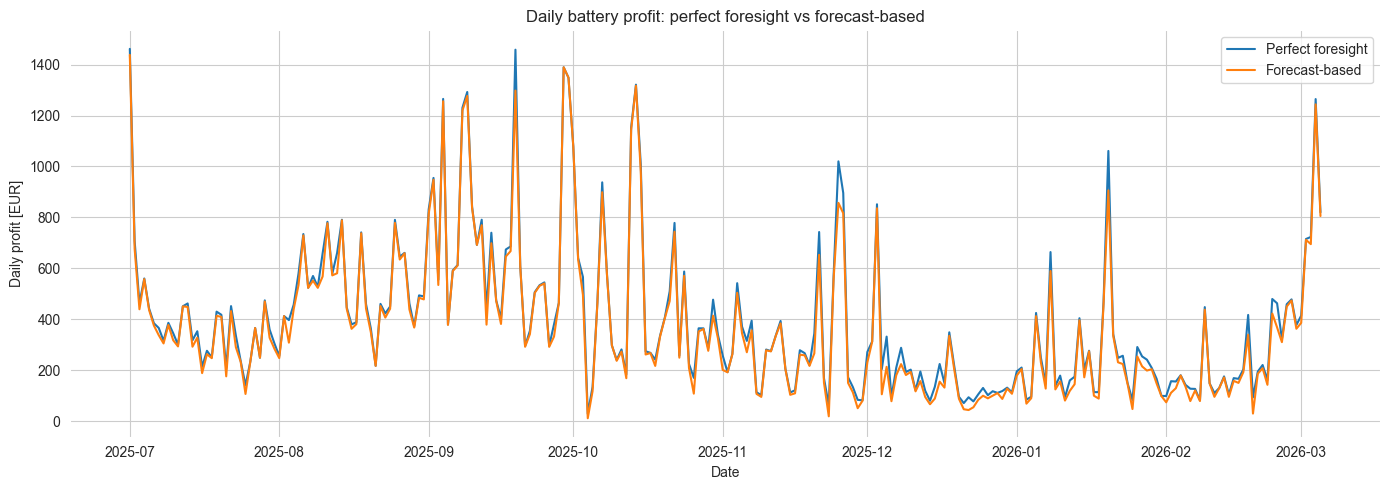

In [173]:
# =========================================================
# 9.3 Plot daily profits for both scenarios
# =========================================================

plt.figure(figsize=(14, 5))

plt.plot(
    daily_profit_compare["date"],
    daily_profit_compare["profit_perfect_eur"],
    label="Perfect foresight"
)

plt.plot(
    daily_profit_compare["date"],
    daily_profit_compare["profit_forecast_eur"],
    label="Forecast-based"
)

plt.xlabel("Date")
plt.ylabel("Daily profit [EUR]")
plt.title("Daily battery profit: perfect foresight vs forecast-based")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

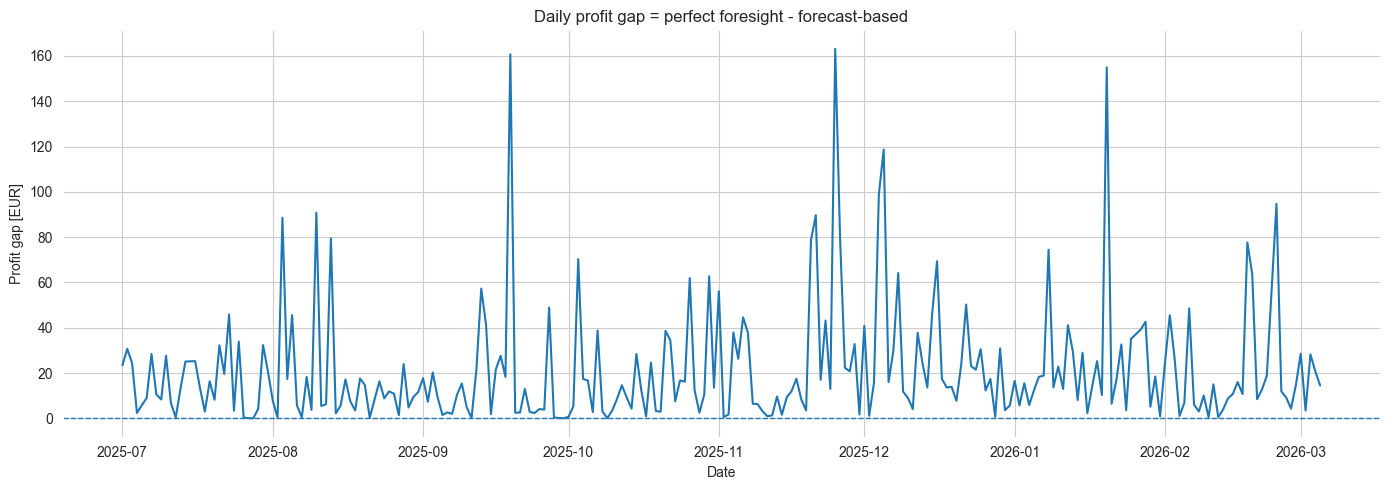

In [174]:
# =========================================================
# 9.4 Plot daily profit gap
# =========================================================

plt.figure(figsize=(14, 5))

plt.plot(
    daily_profit_compare["date"],
    daily_profit_compare["profit_gap_eur"]
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Date")
plt.ylabel("Profit gap [EUR]")
plt.title("Daily profit gap = perfect foresight - forecast-based")
plt.grid(True)
plt.tight_layout()
plt.show()